# Schmitt Trigger using a CMOS Transistor

## Import and Formatting

The goal of this section is to import all the necessary files and libraries required for the subsequent data analysis.  
It also includes setting up the formatting parameters for the plots and visualizations.

### Import

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from PySpice.Spice.Netlist import (
    Circuit, SubCircuitFactory
)
from PySpice.Unit import *
from PySpice.Probe.Plot import plot
from PySpice.Spice.Library import SpiceLibrary
from PySpice.Probe.WaveForm import OperatingPoint

### Formatting

Adjusting Plotly chart settings for clarity and consistency.

In [2]:
# ----  Formatting charts
%matplotlib inline
from IPython.core.pylabtools import figsize
import matplotlib as mpl
mpl.rcParams['lines.linewidth'] = 2.0
mpl.rcParams['axes.edgecolor']  = "#bcbcbc"
mpl.rcParams['patch.linewidth'] = 0.5
mpl.rcParams['legend.fancybox'] = True
mpl.rcParams['axes.facecolor']  = "#eeeeee"
mpl.rcParams['axes.labelsize']  = "large"
mpl.rcParams['axes.grid']       = True
mpl.rcParams['grid.linestyle']  = "--"
mpl.rcParams['patch.edgecolor'] = "#eeeeee"
mpl.rcParams['axes.titlesize']  = "x-large"

## Objective

The objective of this chapter is to present the design of a Schmitt trigger implemented using CMOS transistors. In the previous chapter, a Schmitt trigger based on bipolar transistors was analyzed. Although bipolar implementations are functionally effective, they are relatively complex to implement at the layout and process levels, especially in the context of digital integrated circuits.

In contrast, CMOS technology provides a simpler, more compact, and more scalable fabrication process. It is therefore particularly well suited for large-scale integration and low-power digital systems. For this reason, CMOS-based Schmitt triggers are widely used in modern electronic designs, especially in digital and mixed-signal integrated circuits.

### Circuit

The circuit schematic is shown in Figure [](CMOS_circuit). It consists of four CMOS transistors: two PMOS and two NMOS devices arranged to produce Schmitt trigger behavior.

The objective of the next section is to analyze the operating principle of this circuit and to understand how the interaction between the transistors generates the hysteresis effect.

```{figure} ./images/CMOS_circuit.svg
:name: CMOS_circuit
:align: center
:width: 400px

CMOS-based Schmitt trigger circuit
```

The objective of the next section is to analyze the operating principle of this circuit and to understand how the interaction between the transistors creates the hysteresis effect.

## Circuit Understanding

### Inverter Stage

First, we can identify a structure equivalent to a CMOS inverter formed by transistors M2 and M3. Figure [](#CMOS_circuit_firt_part) illustrates this subcircuit.

```{figure} ./images/CMOS_circuit_firt_part.svg
:name: CMOS_circuit_firt_part
:align: center
:width: 200px

Montage inverseur avec CMOS
```

The operation of this inverter is straightforward and summarized in Figure [](#CMOS_circuit_firt_part_demonstration):

* When a high logic level (`1`) is applied to the input:
  * Transistor **M2** (PMOS) is turned off.
  * Transistor **M3** (NMOS) is turned on.
  * The intermediate output ( V_{int} ) is pulled down to ground.
  * The output is therefore at a low logic level (`0`).

* Conversely, when a low logic level (`0`) is applied to the input:
  * Transistor **M3** is turned off.
  * Transistor **M2** is turned on.
  * The intermediate output ( V_{int} ) is connected to ( V_{DD} ).
  * The output is therefore at a high logic level (`1`).


```{figure} ./images/CMOS_circuit_firt_part_demonstration.svg
:name: CMOS_circuit_firt_part_demonstration
:align: center
:width: 500px

Visualisation des CMOS dans un montage inverseur
```

The following lines of code are intended to simulate the behavior of this first stage of the circuit.

In [3]:
# NMOS and PMOS width configurations (in µm)
# Each pair (Wn, Wp) represents one inverter sizing configuration
nmos_widths = (0.1, 0.1, 0.1)
pmos_widths = (0.2, 0.5, 4.0)

# Lists to store DC sweep results
input_voltages = []
output_voltages = []

# Supply voltage (VDD)
VDD = 1.2  # Volts

# Loop over each (Wn, Wp) sizing pair
for Wn, Wp in zip(nmos_widths, pmos_widths):

    # Create a new circuit instance for each configuration
    circuit = Circuit('CMOS Inverter')

    # Include NMOS and PMOS transistor models (65 nm PTM technology)
    circuit.include('lib/ptm_65nm_nmos_bulk.mod')
    circuit.include('lib/ptm_65nm_pmos_bulk.mod')

    # ------------------------------------------------------------------
    # Power supply definition
    # ------------------------------------------------------------------
    circuit.V('dd', 'vdd', circuit.gnd, VDD @ u_V)

    # ------------------------------------------------------------------
    # Input voltage source (will be swept in DC analysis)
    # ------------------------------------------------------------------
    circuit.V('in', 'vin', circuit.gnd, 0 @ u_V)

    # ------------------------------------------------------------------
    # NMOS transistor
    # Drain  -> vout
    # Gate   -> vin
    # Source -> ground
    # Bulk   -> ground
    # ------------------------------------------------------------------
    circuit.MOSFET(
        'n',
        drain='vout',
        gate='vin',
        source=circuit.gnd,
        bulk=circuit.gnd,
        model='ptm65nm_nmos',
        l=0.35 @ u_um,
        w=Wn @ u_um
    )

    # ------------------------------------------------------------------
    # PMOS transistor
    # Drain  -> vout
    # Gate   -> vin
    # Source -> vdd
    # Bulk   -> vdd
    # ------------------------------------------------------------------
    circuit.MOSFET(
        'p',
        drain='vout',
        gate='vin',
        source='vdd',
        bulk='vdd',
        model='ptm65nm_pmos',
        l=0.35 @ u_um,
        w=Wp @ u_um
    )

    # ------------------------------------------------------------------
    # DC Simulation
    # Sweep input voltage from 0 to VDD with 10 mV step
    # ------------------------------------------------------------------
    simulator = circuit.simulator(temperature=25)
    analysis = simulator.dc(Vin=slice(0, VDD, 0.01))

    # Store input/output voltage characteristics
    input_voltages.append(analysis['vin'])
    output_voltages.append(analysis['vout'])

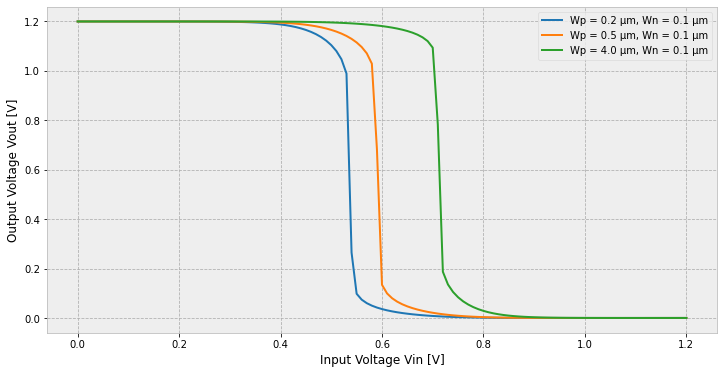

In [6]:
# ------------------------------------------------------------------
# Plot Voltage Transfer Characteristics (VTC)
# ------------------------------------------------------------------
plt.figure(figsize=(12, 6))

# Plot Vout versus Vin for each transistor sizing configuration
for vin_values, vout_values, Wp, Wn in zip(
    input_voltages,
    output_voltages,
    pmos_widths,
    nmos_widths
):
    plt.plot(
        vin_values,
        vout_values,
        label=f'Wp = {Wp} µm, Wn = {Wn} µm'
    )

# Add legend and axis labels
plt.legend(loc='upper right')
plt.xlabel('Input Voltage Vin [V]')
plt.ylabel('Output Voltage Vout [V]')

# Display the figure
plt.show()

Several important observations can be made from this graph.

First, the inverter behavior is clearly visible. When the input voltage $Vin$ is low, the output voltage $Vout$is high, and vice versa. As $Vin$ increases toward $VDD$, the output voltage transitions toward ground. This confirms the expected voltage transfer characteristic (VTC) of a CMOS inverter.

Another important point concerns the influence of the transistor dimensions, specifically the $W/L$ ratio (see Figure [](#CMOS_circuit_W_L)). The graph shows that the switching threshold voltage shifts depending on the relative sizing of the PMOS and NMOS transistors. By adjusting the width-to-length ratio, it is possible to control the inverter’s switching point. This is a key design parameter when tuning threshold levels, especially in circuits such as Schmitt triggers where precise switching behavior is required.

```{figure} ./images/CMOS_circuit_W_L.svg
:name: CMOS_circuit_W_L
:align: center
:width: 400px

Dimensions W L of a gate on a CMOS component
```

Finally, it is worth noting that the voltage plateaus are not perfectly flat, and the transitions are not perfectly vertical. In an idealized inverter model, we often draw the transfer characteristic with sharp vertical transitions and perfectly horizontal logic levels. However, in a real CMOS implementation, the transitions are gradual due to the finite gain of the transistors and their continuous conduction regions. This results in smoother switching behavior rather than abrupt, ideal transitions.

## Reference

## Writing Matrix

| Author | Reviewer | Approver | Section | Date 1 | Date 2 | Date 3 | General Remarks |
|--------|----------|----------|---------|--------|--------|--------|------------------|
| Sacha  | /        | /        | Entire document | 2026-03-04 | / | / | Initial draft of the full document |

## Simulation du circuit complet

In [ ]:
circuit = Circuit('6T CMOS Schmitt Trigger')

# ============================================================
# Models
# ============================================================

circuit.include('lib/ptm_65nm_nmos_bulk.mod')
circuit.include('lib/ptm_65nm_pmos_bulk.mod')

L   = 0.065  # 65 nm
VDD = 1.2
circuit.V('dd', 'vdd', circuit.gnd, VDD @ u_V)

# ============================================================
# Entrée sinusoïdale (lente pour voir l’hystérésis)
# ============================================================

f = 1e3  # 1 kHz (lent pour bien voir la boucle)

circuit.SinusoidalVoltageSource(
    'in', 'vin', circuit.gnd,
    offset=(VDD/2) @ u_V,
    amplitude=(VDD/2) @ u_V,
    frequency=f @ u_Hz
)

# ============================================================
# Stack PMOS (M1 haut, M2 bas)
# PySpice : MOSFET(name, drain, gate, source, bulk)
# ============================================================
circuit.MOSFET(1, 'n1',   'vin', 'vdd', 'vdd',
               model='ptm65nm_pmos', l=L @ u_um, w=1.0 @ u_um)
circuit.MOSFET(2, 'vout', 'vin', 'n1',  'vdd',
               model='ptm65nm_pmos', l=L @ u_um, w=1.0 @ u_um)

# ============================================================
# Stack NMOS (M4 haut, M5 bas)
# ============================================================
circuit.MOSFET(4, 'vout', 'vin', 'n2',          circuit.gnd,
               model='ptm65nm_nmos', l=L @ u_um, w=0.5 @ u_um)
circuit.MOSFET(5, 'n2',   'vin', circuit.gnd,   circuit.gnd,
               model='ptm65nm_nmos', l=L @ u_um, w=0.5 @ u_um)

# ============================================================
# ✅ Feedback : W quasi-égal aux transistors principaux
#    65nm = gain élevé → feedback fort nécessaire
#    W3 ≈ W1=W2,  W6 ≈ W4=W5
# ============================================================
circuit.MOSFET(3, 'n1', 'vout', 'vdd',       'vdd',
               model='ptm65nm_pmos', l=L @ u_um, w=1 @ u_um)
circuit.MOSFET(6, 'n2', 'vout', circuit.gnd, circuit.gnd,
               model='ptm65nm_nmos', l=L @ u_um, w=0.5 @ u_um)

# ============================================================
# Simulation
# ============================================================

simulator = circuit.simulator()
analysis = simulator.transient(
    step_time=0.1@u_us, 
    end_time=5@u_ms, 
    use_initial_condition = True        # ← obligatoire
)

In [ ]:
# ============================================================
# Tracés
# ============================================================
time  = np.array(analysis.time)
vin   = np.array(analysis['vin'])
vout  = np.array(analysis['vout'])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# — Temporel (montre les deux transitions)
axes[0].plot(time * 1e3, vin,  label='Vin',  color='steelblue')
axes[0].plot(time * 1e3, vout, label='Vout', color='darkorange')
axes[0].set_xlabel('Temps (ms)')
axes[0].set_ylabel('Tension (V)')
axes[0].set_title('Réponse temporelle')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# — Boucle d'hystérésis  ← C'EST ICI que tu vois l'effet Schmitt
axes[1].plot(vin, vout, color='purple', linewidth=1.5)
axes[1].set_xlabel('Vin (V)')
axes[1].set_ylabel('Vout (V)')
axes[1].set_title('Courbe de transfert — Boucle d\'hystérésis')
axes[1].axvline(VDD / 2, color='gray', linestyle=':', label='VDD/2')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.tight_layout()
plt.savefig('schmitt_trigger.png', dpi=150)
plt.show()

In [ ]:
# ============================================================
# Extraction des seuils VH et VL
# ============================================================
mid = VDD / 2
# Seuil montant : premier passage de vout sous mid pendant la montée de vin
rising_mask  = vin[:len(vin)//2]
rising_vout  = vout[:len(vout)//2]
fall_idx     = np.where(np.diff(np.sign(rising_vout - mid)) < 0)[0]

falling_mask = vin[len(vin)//2:]
falling_vout = vout[len(vout)//2:]
rise_idx     = np.where(np.diff(np.sign(falling_vout - mid)) > 0)[0]

if fall_idx.size and rise_idx.size:
    VH = rising_mask[fall_idx[0]]
    VL = falling_mask[rise_idx[0]]
    print(f"Seuil haut  VH = {VH:.4f} V")
    print(f"Seuil bas   VL = {VL:.4f} V")
    print(f"Hystérésis  ΔV = {VH - VL:.4f} V")

Je ne sais pas d'ou vient l'erreur, je ne comprend pas pourquoi il n'y a pas d'hystérésis. 
Il faudra par la suite comprendre l'erreur. 